# Comparative Evaluation of Text Semantic Similarity Methods Using Classical and Transformer-Based Representations

In [138]:
import os
import warnings
from os import system

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score

from scipy.stats import pearsonr, spearmanr

from gensim.models import Word2Vec

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

import bert_score

import torch

## Reproducibility

In [49]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## Data loading & preprocessing

### STS-B

In [50]:
stsb_raw = load_dataset("stsb_multi_mt", "en")
stsb_train = pd.DataFrame(stsb_raw["train"]).rename(
    columns={"similarity_score": "score"})
stsb_test = pd.DataFrame(stsb_raw["test"]).rename(
    columns={"similarity_score": "score"})

stsb_train["score_norm"] = stsb_train["score"] / 5.0
stsb_test["score_norm"] = stsb_test["score"] / 5.0

print("── STS-B ──")
print(f"Train: {len(stsb_train)}  |  Test: {len(stsb_test)}")
print(stsb_train[["sentence1", "sentence2", "score_norm"]].head(3))

Using the latest cached version of the dataset since stsb_multi_mt couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'en' at C:\Users\Max\.cache\huggingface\datasets\stsb_multi_mt\en\0.0.0\3acaa3dd8c91649e0b8e627ffad891f059e47c8c (last modified on Fri May 22 15:24:32 2026).


── STS-B ──
  Train: 5749  |  Test: 1379
                                       sentence1  \
0                         A plane is taking off.   
1                A man is playing a large flute.   
2  A man is spreading shreded cheese on a pizza.   

                                           sentence2  score_norm  
0                        An air plane is taking off.        1.00  
1                          A man is playing a flute.        0.76  
2  A man is spreading shredded cheese on an uncoo...        0.76  


### SICK-R

In [68]:
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import pandas as pd

sick_raw = load_dataset("mteb/sickr-sts")["test"]
sick_df = pd.DataFrame(sick_raw)

# sick_train = pd.DataFrame(sick_raw["train"]).rename(
#     columns={
#         "sentence_A": "sentence1",
#         "sentence_B": "sentence2",
#         "relatedness_score": "score"
#     }
# )
sick_train, sick_test = train_test_split(
    sick_df,
    test_size=0.2,
    random_state=42
)

sick_train["score_norm"] = (sick_train["score"] - 1) / 4.0
sick_test["score_norm"] = (sick_test["score"] - 1) / 4.0

print("\n── SICK ──")
print(f"Train: {len(sick_train)}  |  Test: {len(sick_test)}")
print(sick_train[["sentence1", "sentence2", "score_norm"]].head(3))



── SICK ──
Train: 7941  |  Test: 1986
                                              sentence1  \
8878  A little black dog is wearing a red collar and...   
2291                 There is no person playing a piano   
3905  A group of people is gathering at a stand at t...   

                                              sentence2  score_norm  
8878  There is no dog jumping at a shiny blue soccer...        0.65  
2291                       A person is slicing a potato        0.05  
3905               The people are running at a carnival        0.45  


### MRPC

In [64]:
mrpc_raw = load_dataset("nyu-mll/glue", "mrpc")
mrpc_train = pd.DataFrame(mrpc_raw["train"]).rename(
    columns={"sentence1": "sentence1",
             "sentence2": "sentence2",
             "label": "label"})
mrpc_test = pd.DataFrame(mrpc_raw["validation"]).rename(  # MRPC has no public test labels
    columns={"sentence1": "sentence1",
             "sentence2": "sentence2",
             "label": "label"})

print("\n── MRPC ──")
print(f"Train: {len(mrpc_train)}  |  Validation: {len(mrpc_test)}")
print(f"Positive rate (val): {mrpc_test['label'].mean():.2%}")
print(mrpc_train[["sentence1", "sentence2", "label"]].head(3))

Generating test split: 100%|██████████| 1725/1725 [00:00<00:00, 574995.98 examples/s]



── MRPC ──
  Train: 3668  |  Validation: 408
  Positive rate (val): 68.38%
                                           sentence1  \
0  Amrozi accused his brother , whom he called " ...   
1  Yucaipa owned Dominick 's before selling the c...   
2  They had published an advertisement on the Int...   

                                           sentence2  label  
0  Referring to him as only " the witness " , Amr...      1  
1  Yucaipa bought Dominick 's in 1995 for $ 693 m...      0  
2  On June 10 , the ship 's owners had published ...      1  


### STS-Annual

In [65]:
sts_annual_raw = load_dataset("mteb/stsbenchmark-sts", split="test")
sts_annual_df = pd.DataFrame(sts_annual_raw).rename(
    columns={"sentence1": "sentence1",
             "sentence2": "sentence2",
             "score": "score"})

sts_annual_df["score_norm"] = sts_annual_df["score"] / 5.0

sts_annual_train_raw = load_dataset("mteb/stsbenchmark-sts", split="train")
sts_annual_train = pd.DataFrame(sts_annual_train_raw).rename(
    columns={"sentence1": "sentence1",
             "sentence2": "sentence2",
             "score": "score"})
sts_annual_train["score_norm"] = sts_annual_train["score"] / 5.0

print("\n── STS-Annual ──")
print(f"Train: {len(sts_annual_train)}  |  Test: {len(sts_annual_df)}")
if "genre" in sts_annual_df.columns:
    print(f"Domains: {sts_annual_df['genre'].value_counts().to_dict()}")
print(sts_annual_df[["sentence1", "sentence2", "score_norm"]].head(3))

Generating test split: 100%|██████████| 1379/1379 [00:00<00:00, 137923.15 examples/s]



── STS-Annual ──
  Train: 5749  |  Test: 1379
  Domains: {'main-captions': 625, 'main-news': 500, 'main-forums': 254}
                                       sentence1  \
0                    A girl is styling her hair.   
1       A group of men play soccer on the beach.   
2  One woman is measuring another woman's ankle.   

                                          sentence2  score_norm  
0                      A girl is brushing her hair.        0.50  
1  A group of boys are playing soccer on the beach.        0.72  
2           A woman measures another woman's ankle.        1.00  


### QQP

In [70]:
qqp_raw = load_dataset("nyu-mll/glue", "qqp")
qqp_train = pd.DataFrame(qqp_raw["train"]).rename(
    columns={"question1": "sentence1",
             "question2": "sentence2",
             "label": "label"})
qqp_test = pd.DataFrame(qqp_raw["validation"]).rename(
    columns={"question1": "sentence1",
             "question2": "sentence2",
             "label": "label"})

qqp_train_sample = qqp_train.sample(n=min(5000, len(qqp_train)),
                                    random_state=RANDOM_SEED)

print("\n── QQP ──")
print(f"Train (full): {len(qqp_train)}  |  Val: {len(qqp_test)}")
print(f"Positive rate (val): {qqp_test['label'].mean():.2%}")
print(qqp_train[["sentence1", "sentence2", "label"]].head(3))

Generating test split: 100%|██████████| 390965/390965 [00:00<00:00, 2820153.27 examples/s]



── QQP ──
  Train (full): 363846  |  Val: 40430
  Positive rate (val): 36.82%
                                           sentence1  \
0  How is the life of a math student? Could you d...   
1                How do I control my horny emotions?   
2       What causes stool color to change to yellow?   

                                           sentence2  label  
0  Which level of prepration is enough for the ex...      0  
1                 How do you control your horniness?      1  
2  What can cause stool to come out as little balls?      0  


### Score distributions

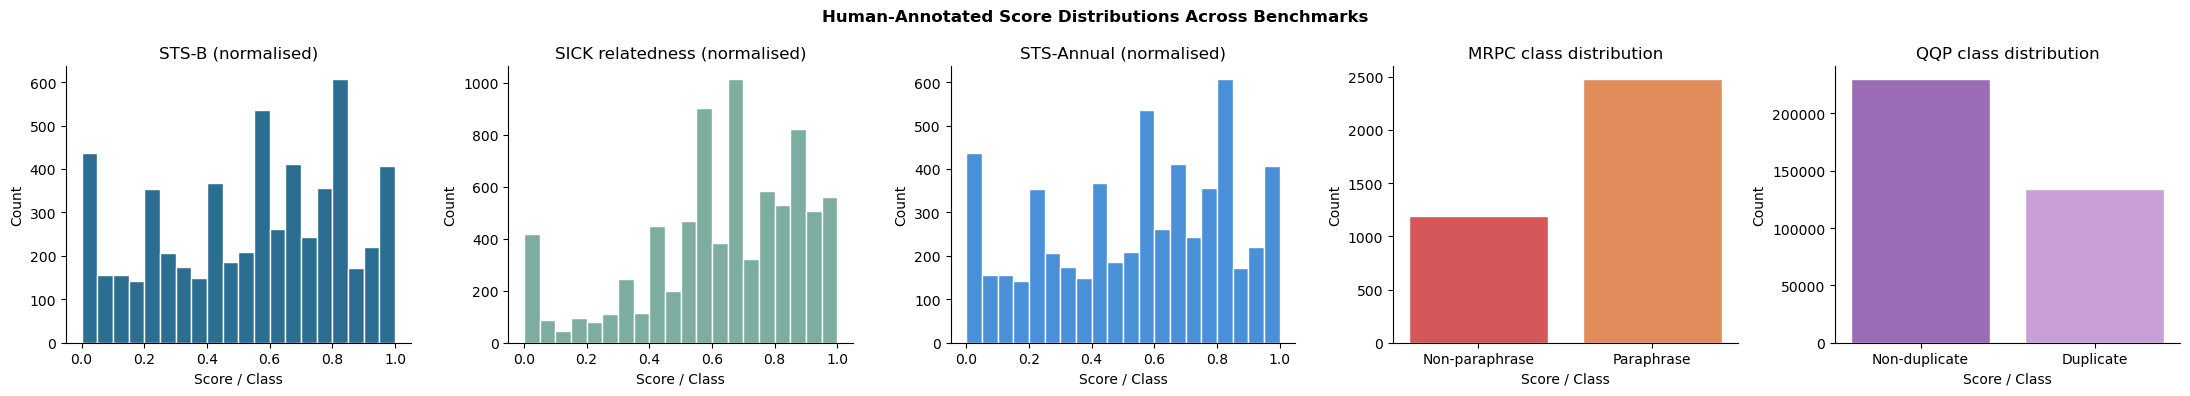

In [71]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Human-Annotated Score Distributions Across Benchmarks",
             fontsize=12, fontweight="bold")

axes[0].hist(stsb_train["score_norm"], bins=20,
             color="#2C6E91", edgecolor="white")
axes[0].set_title("STS-B (normalised)")

axes[1].hist(sick_train["score_norm"], bins=20,
             color="#7DADA0", edgecolor="white")
axes[1].set_title("SICK relatedness (normalised)")

axes[2].hist(sts_annual_train["score_norm"], bins=20,
             color="#4A90D9", edgecolor="white")
axes[2].set_title("STS-Annual (normalised)")

mrpc_counts = mrpc_train["label"].value_counts()
axes[3].bar(["Non-paraphrase", "Paraphrase"], [mrpc_counts[0], mrpc_counts[1]],
            color=["#D4575A", "#E08C5B"], edgecolor="white")
axes[3].set_title("MRPC class distribution")

qqp_counts = qqp_train["label"].value_counts()
axes[4].bar(["Non-duplicate", "Duplicate"], [qqp_counts[0], qqp_counts[1]],
            color=["#9B6BB5", "#C89FD8"], edgecolor="white")
axes[4].set_title("QQP class distribution")

for ax in axes:
    ax.set_xlabel("Score / Class")
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Model definitions

### TF-IDF

In [72]:
def build_tfidf(train_dfs):
    """Fit a single TF-IDF vectorizer on all training corpora."""
    corpus = []
    for df in train_dfs:
        corpus += df["sentence1"].tolist() + df["sentence2"].tolist()
    v = TfidfVectorizer()
    v.fit(corpus)
    return v


tfidf = build_tfidf([stsb_train, sick_train, mrpc_train,
                     sts_annual_train, qqp_train_sample])


def tfidf_sim(s1, s2):
    v1 = tfidf.transform([s1])
    v2 = tfidf.transform([s2])
    return float(cosine_similarity(v1, v2)[0][0])


def tfidf_batch(df):
    return [tfidf_sim(r.sentence1, r.sentence2) for _, r in df.iterrows()]

### Word2Vec mean-pooling

In [73]:
all_sentences_train = (
        stsb_train["sentence1"].tolist() + stsb_train["sentence2"].tolist() +
        sick_train["sentence1"].tolist() + sick_train["sentence2"].tolist() +
        mrpc_train["sentence1"].tolist() + mrpc_train["sentence2"].tolist() +
        sts_annual_train["sentence1"].tolist() + sts_annual_train["sentence2"].tolist() +
        qqp_train_sample["sentence1"].tolist() + qqp_train_sample["sentence2"].tolist()
)
tokenized = [s.lower().split() for s in all_sentences_train]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100, window=5, min_count=1, workers=4, seed=RANDOM_SEED,
)


def sent_vec(sentence):
    words = sentence.lower().split()
    vecs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(100)


def w2v_sim(s1, s2):
    v1, v2 = sent_vec(s1), sent_vec(s2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8))


def w2v_batch(df):
    return [w2v_sim(r.sentence1, r.sentence2) for _, r in df.iterrows()]

### Pretrained SBERT

In [97]:
sbert = SentenceTransformer("all-MiniLM-L12-v2")


def sbert_batch(df, model=None):
    """Return cosine similarities for all pairs using batch encoding."""
    m = model or sbert
    s1s = df["sentence1"].tolist()
    s2s = df["sentence2"].tolist()
    e1 = m.encode(s1s, batch_size=64, show_progress_bar=False, convert_to_numpy=True)
    e2 = m.encode(s2s, batch_size=64, show_progress_bar=False, convert_to_numpy=True)
    e1 = e1 / (np.linalg.norm(e1, axis=1, keepdims=True) + 1e-8)
    e2 = e2 / (np.linalg.norm(e2, axis=1, keepdims=True) + 1e-8)
    return (e1 * e2).sum(axis=1).tolist()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 813.03it/s]


### Fine-tuned SBERT (trained on STS-B only)

In [77]:
print("\n[INFO] Fine-tuning SBERT on STS-B training subset …")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using \"{device}\"")
ft_model = SentenceTransformer("all-MiniLM-L12-v2", device=device)
sample_df = stsb_train.sample(5000, random_state=RANDOM_SEED)

train_samples = [
    InputExample(texts=[r.sentence1, r.sentence2], label=float(r.score_norm))
    for _, r in sample_df.iterrows()
]

train_loader = DataLoader(train_samples, shuffle=True, batch_size=16)
loss_fn = losses.CosineSimilarityLoss(ft_model)

ft_model.fit(
    train_objectives=[(train_loader, loss_fn)],
    epochs=3,
    warmup_steps=100,
    show_progress_bar=True,
)


def ft_sbert_batch(df):
    return sbert_batch(df, model=ft_model)


[INFO] Fine-tuning SBERT on STS-B training subset …
using "cuda"


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6861.78it/s]


Step,Training Loss
500,0.019233


### BERTScore

In [78]:
def bertscore_batch(df):
    _, _, f1 = bert_score.score(
        cands=df["sentence1"].tolist(),
        refs=df["sentence2"].tolist(),
        lang="en",
        model_type="roberta-large",
        batch_size=32,
        verbose=True,
    )
    return f1.numpy().tolist()

## Evaluation helpers

In [79]:
def regression_metrics(gold, preds):
    """Return Pearson r and Spearman ρ."""
    r_p, _ = pearsonr(gold, preds)
    r_s, _ = spearmanr(gold, preds)
    return round(r_p, 4), round(r_s, 4)


def classification_metrics(labels, scores, threshold=0.5):
    """
    Binarise continuous similarity scores at `threshold` and compute
    Accuracy and macro-F1.  The threshold is tuned on the training set.
    """
    preds = (np.array(scores) >= threshold).astype(int)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return round(acc, 4), round(f1, 4)


def best_threshold(train_labels, train_scores):
    """Grid-search threshold in [0.1, 0.9] that maximises F1 on training data."""
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.95, 0.05):
        _, f1 = classification_metrics(train_labels, train_scores, threshold=t)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 2)


def fisher_z_test(r1, r2, n):
    """Two-tailed Fisher z-test for difference between Pearson correlations."""
    z1 = np.arctanh(np.clip(r1, -0.9999, 0.9999))
    z2 = np.arctanh(np.clip(r2, -0.9999, 0.9999))
    se = np.sqrt(2.0 / (n - 3))
    z_stat = (z1 - z2) / se
    from scipy.stats import norm
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 \
        else "*" if p_val < 0.05 else "ns"
    return round(z_stat, 3), sig

## Running all models on all datasets

In [80]:
MODEL_FNS = {
    "TF-IDF": tfidf_batch,
    "Word2Vec": w2v_batch,
    "SBERT (pretrained)": sbert_batch,
    "SBERT (fine-tuned)": ft_sbert_batch,
    "BERTScore F1": bertscore_batch,
}

COLORS = {
    "TF-IDF": "#5E7EA8",
    "Word2Vec": "#7DADA0",
    "SBERT (pretrained)": "#E08C5B",
    "SBERT (fine-tuned)": "#D4575A",
    "BERTScore F1": "#9B6BB5",
}

### Regression datasets

In [81]:
regression_results = {}

for ds_name, test_df, train_df_ref in [
    ("STS-B", stsb_test, stsb_train),
    ("SICK", sick_test, sick_train),
    ("STS-Annual", sts_annual_df, sts_annual_train),
]:
    gold = test_df["score_norm"].values
    rows = []

    for model_name, fn in MODEL_FNS.items():
        print(f"\n[{ds_name}] Running {model_name} …")
        preds = fn(test_df)
        r_p, r_s = regression_metrics(gold, preds)
        rows.append({
            "Model": model_name,
            "Pearson r": r_p,
            "Spearman ρ": r_s,
            "_preds": preds,
        })

    df_res = pd.DataFrame(rows).sort_values("Pearson r", ascending=False)
    df_res["Rank"] = range(1, len(df_res) + 1)
    regression_results[ds_name] = df_res

    print(f"\n── Table: {ds_name} Results ──")
    print(df_res[["Rank", "Model", "Pearson r", "Spearman ρ"]].to_string(index=False))



[STS-B] Running TF-IDF …

[STS-B] Running Word2Vec …

[STS-B] Running SBERT (pretrained) …


Batches: 100%|██████████| 22/22 [00:00<00:00, 75.19it/s]



[STS-B] Running SBERT (fine-tuned) …


Batches: 100%|██████████| 22/22 [00:00<00:00, 72.90it/s]



[STS-B] Running BERTScore F1 …


...

calculating scores...
computing bert embedding.


100%|██████████| 80/80 [00:02<00:00, 33.06it/s]


computing greedy matching.


100%|██████████| 44/44 [00:00<00:00, 100.03it/s]

done in 2.87 seconds, 480.48 sentences/sec

── Table: STS-Annual Results ──
 Rank              Model  Pearson r  Spearman ρ
    1 SBERT (fine-tuned)     0.8681      0.8660
    2 SBERT (pretrained)     0.8376      0.8309
    3             TF-IDF     0.6904      0.6734
    4       BERTScore F1     0.5690      0.5692
    5           Word2Vec     0.1087      0.1245


### Classification datasets

In [125]:
classification_results = {}

for ds_name, train_df, test_df in [
    ("MRPC", mrpc_train,        mrpc_test),
    ("QQP",  qqp_train_sample,  qqp_test),
]:
    cls_rows = []
    for model_name, fn in MODEL_FNS.items():
        print(f"\n[{ds_name}] Running {model_name} …")

        train_scores = fn(train_df)
        test_scores  = fn(test_df)

        t = best_threshold(train_df["label"].tolist(), train_scores)
        acc, f1 = classification_metrics(test_df["label"].tolist(), test_scores, t)

        cls_rows.append({
            "Model":     model_name,
            "Threshold": t,
            "Accuracy":  acc,
            "F1":        f1,
            "_preds":    test_scores,
        })

    cls_df = pd.DataFrame(cls_rows).sort_values("F1", ascending=False)
    cls_df["Rank"] = range(1, len(cls_df) + 1)
    classification_results[ds_name] = cls_df

    print(f"\n── Table: {ds_name} Results ──")
    print(cls_df[["Rank", "Model", "Threshold", "Accuracy", "F1"]].to_string(index=False))

mrpc_df = classification_results["MRPC"]
qqp_df  = classification_results["QQP"]


[MRPC] Running TF-IDF …

[MRPC] Running Word2Vec …

[MRPC] Running SBERT (pretrained) …


Batches: 100%|██████████| 7/7 [00:00<00:00, 55.18it/s]



[MRPC] Running SBERT (fine-tuned) …

[MRPC] Running BERTScore F1 …


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6268.89it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


...

calculating scores...
computing bert embedding.


100%|██████████| 2292/2292 [01:09<00:00, 33.06it/s]


computing greedy matching.


100%|██████████| 1264/1264 [00:13<00:00, 96.56it/s]


done in 82.63 seconds, 489.28 sentences/sec

── Table: QQP Results ──
 Rank              Model  Threshold  Accuracy     F1
    1 SBERT (fine-tuned)       0.70    0.7633 0.7390
    2 SBERT (pretrained)       0.75    0.7660 0.7373
    3       BERTScore F1       0.90    0.6192 0.6514
    4             TF-IDF       0.40    0.6360 0.6409
    5           Word2Vec       0.85    0.5020 0.5592


## Visualization

In [113]:
import os
os.makedirs("output", exist_ok=True)

### Multi-dataset bar chart

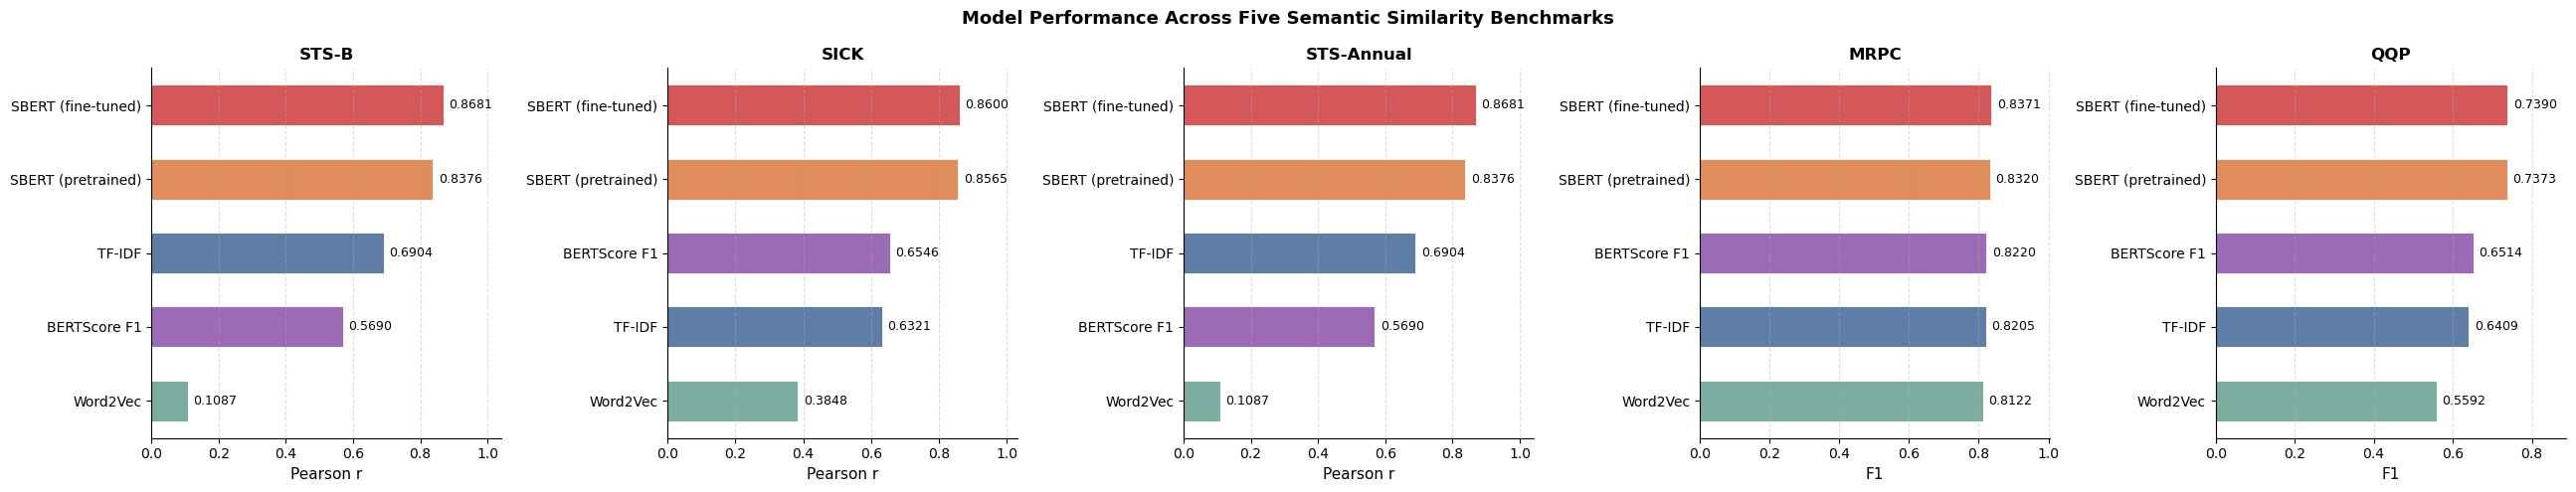

In [114]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5), sharey=False)
fig.suptitle("Model Performance Across Five Semantic Similarity Benchmarks",
             fontsize=13, fontweight="bold")

plot_configs = [
    ("STS-B",       regression_results["STS-B"],       "Pearson r"),
    ("SICK",        regression_results["SICK"],         "Pearson r"),
    ("STS-Annual",  regression_results["STS-Annual"],   "Pearson r"),
    ("MRPC",        mrpc_df,                            "F1"),
    ("QQP",         qqp_df,                             "F1"),
]

for ax, (ds_name, df, metric) in zip(axes, plot_configs):
    ordered = df.sort_values(metric, ascending=True)
    bars = ax.barh(
        ordered["Model"],
        ordered[metric],
        color=[COLORS[m] for m in ordered["Model"]],
        edgecolor="white", linewidth=0.6, height=0.55,
    )
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_xlim(0, min(1.1, ordered[metric].max() * 1.2))
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.tight_layout()
fig.savefig("output/model_comparison_all.png", dpi=150, bbox_inches="tight")
plt.show()

### Heatmap: Pearson r across datasets

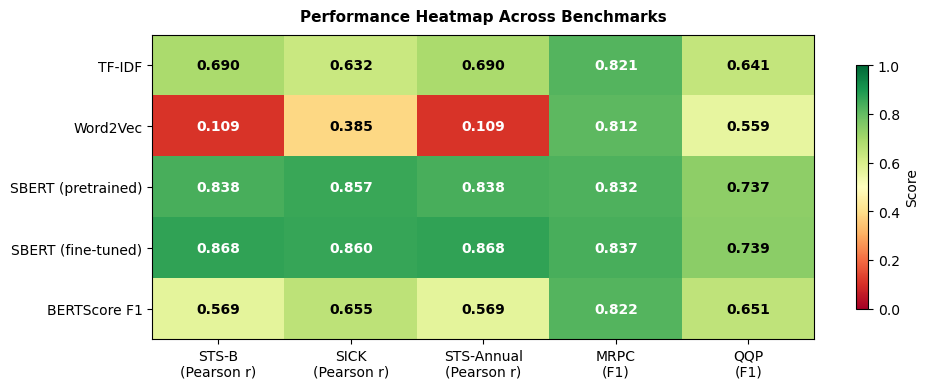

In [115]:
model_order = list(MODEL_FNS.keys())

heat_data = np.zeros((len(model_order), 5))
for i, mname in enumerate(model_order):
    row_stsb   = regression_results["STS-B"].set_index("Model").loc[mname]
    row_sick   = regression_results["SICK"].set_index("Model").loc[mname]
    row_stsa   = regression_results["STS-Annual"].set_index("Model").loc[mname]
    row_mrpc   = mrpc_df.set_index("Model").loc[mname]
    row_qqp    = qqp_df.set_index("Model").loc[mname]
    heat_data[i] = [
        row_stsb["Pearson r"],
        row_sick["Pearson r"],
        row_stsa["Pearson r"],
        row_mrpc["F1"],
        row_qqp["F1"],
    ]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heat_data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(
    ["STS-B\n(Pearson r)", "SICK\n(Pearson r)", "STS-Annual\n(Pearson r)",
     "MRPC\n(F1)", "QQP\n(F1)"],
    fontsize=10)
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order, fontsize=10)
ax.set_title("Performance Heatmap Across Benchmarks", fontsize=11,
             fontweight="bold", pad=10)

for i in range(len(model_order)):
    for j in range(5):
        val   = heat_data[i, j]
        color = "black" if 0.3 < val < 0.75 else "white"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=10, color=color, fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.8, label="Score")
fig.tight_layout()
fig.savefig("output/heatmap_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()


### Scatter: predicted vs gold, all models, STS-B

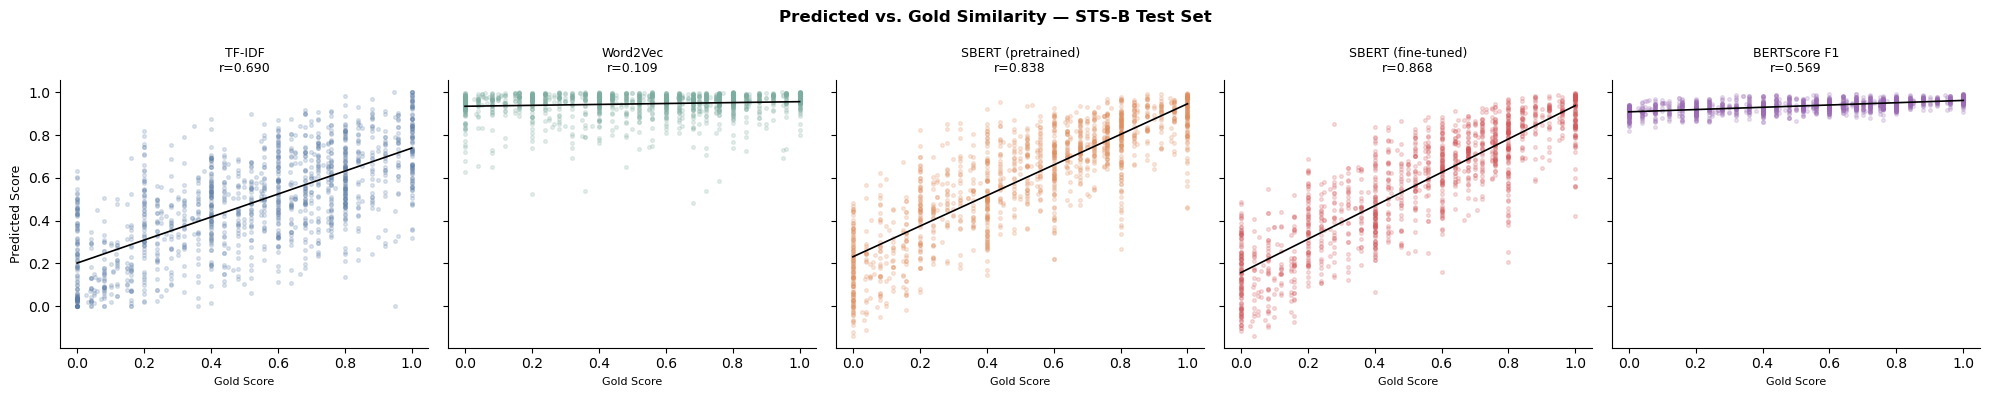

In [116]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle("Predicted vs. Gold Similarity — STS-B Test Set", fontsize=12,
             fontweight="bold")

gold_stsb = stsb_test["score_norm"].values

for ax, row in regression_results["STS-B"].iterrows():
    mname = row["Model"]
    preds = np.array(row["_preds"])
    r_p   = row["Pearson r"]
    ax    = axes[list(MODEL_FNS.keys()).index(mname)]
    ax.scatter(gold_stsb, preds, alpha=0.20, s=7,
               color=COLORS[mname], rasterized=True)
    m, b  = np.polyfit(gold_stsb, preds, 1)
    xl    = np.linspace(0, 1, 100)
    ax.plot(xl, m * xl + b, color="black", linewidth=1.2)
    ax.set_title(f"{mname}\nr={r_p:.3f}", fontsize=9)
    ax.set_xlabel("Gold Score", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Predicted Score", fontsize=9)
fig.tight_layout()
fig.savefig("output/scatter_stsb.png", dpi=150, bbox_inches="tight")
plt.show()


### Statistical significance

In [117]:
n_stsb = len(stsb_test)
pearson_map = dict(zip(
    regression_results["STS-B"]["Model"],
    regression_results["STS-B"]["Pearson r"]
))
model_names = list(pearson_map.keys())

sig_rows = []
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        z, sig = fisher_z_test(pearson_map[m1], pearson_map[m2], n_stsb)
        sig_rows.append({"Comparison": f"{m1}  vs  {m2}",
                         "z-stat": z, "sig": sig})

sig_df = pd.DataFrame(sig_rows)
print("\n── Table: Pairwise Significance (STS-B Pearson r, Fisher z) ──")
print(sig_df.to_string(index=False))



── Table: Pairwise Significance (STS-B Pearson r, Fisher z) ──
                                Comparison  z-stat sig
SBERT (fine-tuned)  vs  SBERT (pretrained)   2.944  **
            SBERT (fine-tuned)  vs  TF-IDF  12.501 ***
      SBERT (fine-tuned)  vs  BERTScore F1  17.817 ***
          SBERT (fine-tuned)  vs  Word2Vec  31.900 ***
            SBERT (pretrained)  vs  TF-IDF   9.557 ***
      SBERT (pretrained)  vs  BERTScore F1  14.873 ***
          SBERT (pretrained)  vs  Word2Vec  28.956 ***
                  TF-IDF  vs  BERTScore F1   5.316 ***
                      TF-IDF  vs  Word2Vec  19.399 ***
                BERTScore F1  vs  Word2Vec  14.083 ***


## Cross-dataset generalisation analysis

In [132]:
print("\n── Table: Cross-Dataset Rank Summary ──")
rank_table = pd.DataFrame({"Model": model_order})

for ds_name, df, metric in plot_configs:
    rank_col = df.set_index("Model")["Rank"].rename(f"Rank ({ds_name}/{metric})")
    rank_table = rank_table.merge(rank_col, left_on="Model", right_index=True, how="left")

rank_table.to_csv("output/cross_dataset_rank_summary.csv", index=False)

print(rank_table.to_string(index=False))



── Table: Cross-Dataset Rank Summary ──
             Model  Rank (STS-B/Pearson r)  Rank (SICK/Pearson r)  Rank (STS-Annual/Pearson r)  Rank (MRPC/F1)  Rank (QQP/F1)
            TF-IDF                       3                      4                            3               4              4
          Word2Vec                       5                      5                            5               5              5
SBERT (pretrained)                       2                      2                            2               2              2
SBERT (fine-tuned)                       1                      1                            1               1              1
      BERTScore F1                       4                      3                            4               3              3


### QQP vs MRPC Classification F1 comparison

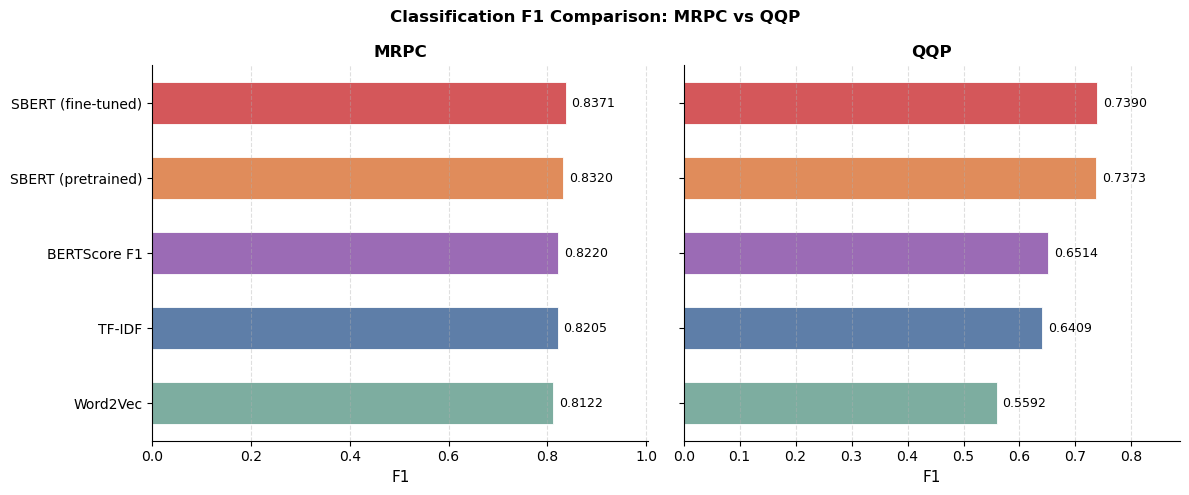

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle("Classification F1 Comparison: MRPC vs QQP", fontsize=12,
             fontweight="bold")

for ax, (ds_name, cls_df_plot) in zip(axes, [("MRPC", mrpc_df), ("QQP", qqp_df)]):
    ordered = cls_df_plot.sort_values("F1", ascending=True)
    bars = ax.barh(
        ordered["Model"],
        ordered["F1"],
        color=[COLORS[m] for m in ordered["Model"]],
        edgecolor="white", linewidth=0.6, height=0.55,
    )
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_xlim(0, min(1.1, ordered["F1"].max() * 1.2))
    ax.set_xlabel("F1", fontsize=11)
    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.tight_layout()
fig.savefig("output/classification_comparison_mrpc_qqp.png", dpi=150, bbox_inches="tight")
plt.show()


## Error analisys

### STS-B: where TF-IDF and fine-tuned SBERT disagree most

In [134]:
stsb_err = stsb_test.copy()

stsb_err["tfidf"] = regression_results["STS-B"].set_index("Model").loc[
    "TF-IDF", "_preds"
]

stsb_err["sbert_ft"] = regression_results["STS-B"].set_index("Model").loc[
    "SBERT (fine-tuned)", "_preds"
]

stsb_err["gap"] = (stsb_err["sbert_ft"] - stsb_err["tfidf"]).abs()

top10 = stsb_err.nlargest(10, "gap")[
    ["sentence1", "sentence2", "score_norm", "tfidf", "sbert_ft", "gap"]
]

print("\n── Table: Top-10 STS-B Disagreement Cases ──")
with pd.option_context("display.max_colwidth", 50):
    print(top10.to_string(index=False))

# --- SAVE TO CSV ---
import os

os.makedirs("output", exist_ok=True)
top10.to_csv("output/stsb_top10_disagreement_cases.csv", index=False)


── Table: Top-10 STS-B Disagreement Cases ──
                                                 sentence1                                              sentence2  score_norm    tfidf  sbert_ft      gap
                              The lady peeled the potatoe.                           A woman is peeling a potato.        0.95 0.000000  0.863662 0.863662
                               A person is slicing onions.                           Someone is slicing an onion.        0.92 0.279764  0.946518 0.666753
                  A yellow car speeds along a snowy field.               A yellow car drives quickly in the snow.        0.88 0.242751  0.884399 0.641648
  A man uses a chainsaw to sculpt a phallic ice sculpture. A man is using a chainsaw to carve a wooden sculpture.        0.52 0.130721  0.768288 0.637568
                                     It's not a good idea.                           It's a good idea to do both.        0.20 0.746697  0.159432 0.587265
                  A man is pla

### MRPC and QQP: false positives and false negatives

In [135]:
for cls_name, cls_test_df, cls_df_ref in [
    ("MRPC", mrpc_test, mrpc_df),
    ("QQP",  qqp_test,  qqp_df),
]:
    err_df = cls_test_df.copy()

    err_df["sbert_ft_score"] = cls_df_ref.set_index("Model").loc[
        "SBERT (fine-tuned)", "_preds"
    ]

    sbert_t = cls_df_ref.set_index("Model").loc["SBERT (fine-tuned)", "Threshold"]
    err_df["sbert_ft_pred"] = (err_df["sbert_ft_score"] >= sbert_t).astype(int)

    fp = err_df[(err_df["label"] == 0) & (err_df["sbert_ft_pred"] == 1)]
    fn = err_df[(err_df["label"] == 1) & (err_df["sbert_ft_pred"] == 0)]

    print(f"\n{cls_name} — SBERT (fine-tuned) error breakdown:")
    print(f"  False Positives: {len(fp)}")
    print(f"  False Negatives: {len(fn)}")

    print(f"False Positive examples ({cls_name}):")
    with pd.option_context("display.max_colwidth", 70):
        print(fp[["sentence1", "sentence2", "sbert_ft_score"]]
              .head(3).to_string(index=False))

    # --- SAVE TO CSV ---
    fp.to_csv(f"output/{cls_name.lower()}_false_positives.csv", index=False)
    fn.to_csv(f"output/{cls_name.lower()}_false_negatives.csv", index=False)


MRPC — SBERT (fine-tuned) error breakdown:
  False Positives: 78
  False Negatives: 22
False Positive examples (MRPC):
                                                                                                                  sentence1                                                                                                                             sentence2  sbert_ft_score
   The dollar was at 116.92 yen against the yen , flat on the session , and at 1.2891 against the Swiss franc , also flat . The dollar was at 116.78 yen JPY = , virtually flat on the session , and at 1.2871 against the Swiss franc CHF = , down 0.1 percent .        0.750830
                                                               No dates have been set for the civil or the criminal trial .                                         No dates have been set for the criminal or civil cases , but Shanley has pleaded not guilty .        0.729647
While dioxin levels in the environment were up last year ,

## QUALITATIVE PROBES

In [136]:
def compare_sentences(s1, s2, label=None):
    print(f"\n  S1 : {s1}")
    print(f"  S2 : {s2}")
    if label is not None:
        print(f"  Gold: {label}")
    print("  " + "─" * 65)
    for name, fn in [
        ("TF-IDF",             lambda: tfidf_sim(s1, s2)),
        ("Word2Vec",           lambda: w2v_sim(s1, s2)),
        ("SBERT (pretrained)", lambda: sbert_batch(pd.DataFrame(
            [{"sentence1": s1, "sentence2": s2}]))[0]),
        ("SBERT (fine-tuned)", lambda: ft_sbert_batch(pd.DataFrame(
            [{"sentence1": s1, "sentence2": s2}]))[0]),
    ]:
        print(f"  {name:<25} {fn():.4f}")

print("\n[A] Lexical paraphrase — high semantic overlap, low surface overlap")
compare_sentences(
    "The cat is sleeping on the sofa.",
    "The feline is dozing on the couch."
)

print("\n[B] Syntactic ambiguity — same surface, different predicate structure")
compare_sentences(
    "The chicken is ready to eat.",
    "The chicken is eating."
)

print("\n[C] Instrument vs. patient attachment")
compare_sentences(
    "I saw the man with the telescope.",
    "I used a telescope to see the man."
)

print("\n[D] Negation — near-identical surface, opposite meaning")
compare_sentences(
    "The patient recovered quickly after surgery.",
    "The patient did not recover after surgery."
)

print("\n[E] Domain-register paraphrase")
compare_sentences(
    "The stock market fell sharply yesterday.",
    "Equity markets recorded significant losses on Tuesday."
)

print("\n[F] SICK-style compositional pair (image captions)")
compare_sentences(
    "A dog is running across the grass.",
    "No dog is running across the grass.",
    label="Low relatedness (contradiction)"
)

print("\n[G] MRPC-style paraphrase (news text)")
compare_sentences(
    "The team won the championship for the third time in a row.",
    "The side claimed a third consecutive title.",
    label="Paraphrase (label=1)"
)


[A] Lexical paraphrase — high semantic overlap, low surface overlap

  S1 : The cat is sleeping on the sofa.
  S2 : The feline is dozing on the couch.
  ─────────────────────────────────────────────────────────────────
  TF-IDF                    0.2173
  Word2Vec                  0.9820
  SBERT (pretrained)        0.6624
  SBERT (fine-tuned)        0.6698

[B] Syntactic ambiguity — same surface, different predicate structure

  S1 : The chicken is ready to eat.
  S2 : The chicken is eating.
  ─────────────────────────────────────────────────────────────────
  TF-IDF                    0.4891
  Word2Vec                  0.8819
  SBERT (pretrained)        0.8735
  SBERT (fine-tuned)        0.8757

[C] Instrument vs. patient attachment

  S1 : I saw the man with the telescope.
  S2 : I used a telescope to see the man.
  ─────────────────────────────────────────────────────────────────
  TF-IDF                    0.6067
  Word2Vec                  0.8817
  SBERT (pretrained)        0.915